# Car Price Prediction with Machine Learning

## Internship Task 3

The price of a car depends on many factors such as present price, kilometers driven, fuel type, transmission type, owner type, and many more.

In this project, we build a Machine Learning model to predict the selling price of cars using Python and Scikit-Learn.

### Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In [ ]:
df = pd.read_csv('car data.csv')

### Display first 5 rows

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Dataset Information

In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       

### Dataset Columns

In [ ]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


### Selling Price Distribution

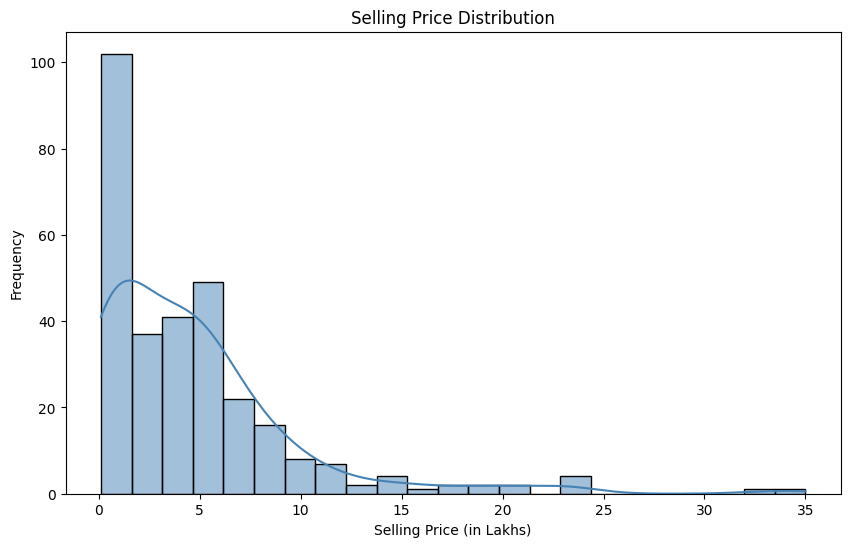

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Selling_Price'], kde=True, color='steelblue')

plt.title("Selling Price Distribution")

plt.xlabel("Selling Price (in Lakhs)")

plt.ylabel("Frequency")

plt.show()

### Selling Price by Fuel Type

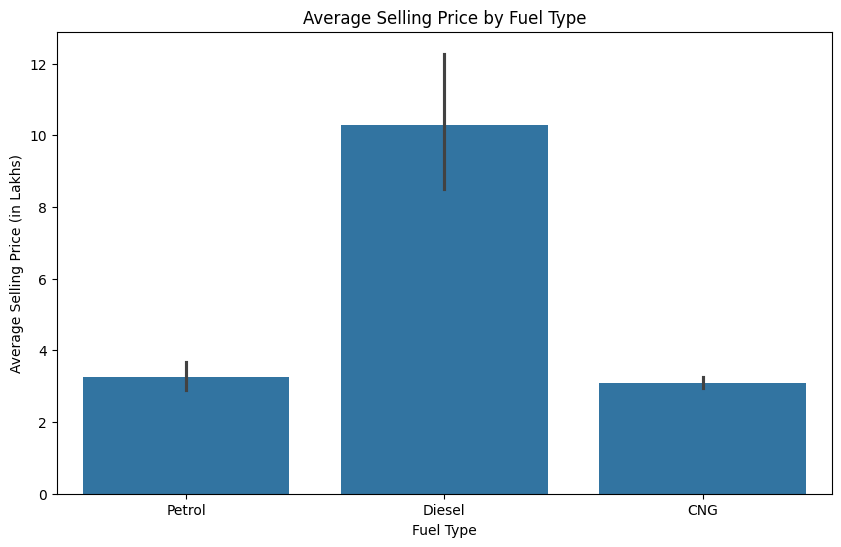

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(x='Fuel_Type', y='Selling_Price', data=df)

plt.title("Average Selling Price by Fuel Type")

plt.xlabel("Fuel Type")

plt.ylabel("Average Selling Price (in Lakhs)")

plt.show()

### Selling Price by Transmission Type

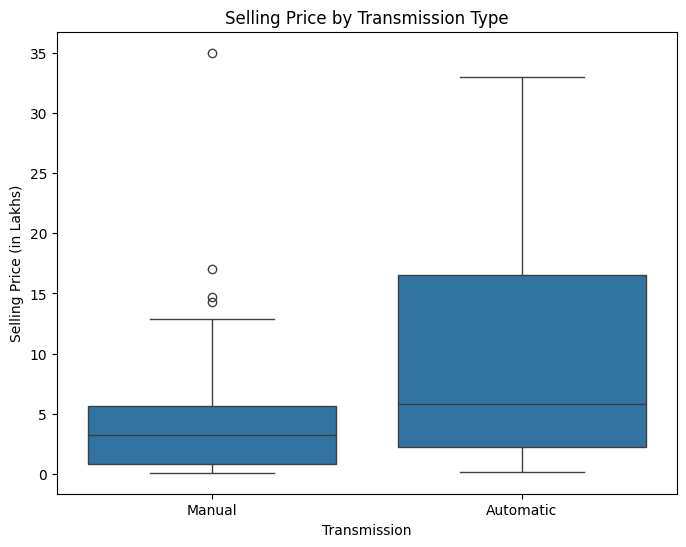

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Transmission', y='Selling_Price', data=df)

plt.title("Selling Price by Transmission Type")

plt.xlabel("Transmission")

plt.ylabel("Selling Price (in Lakhs)")

plt.show()

### Kilometers Driven vs Selling Price

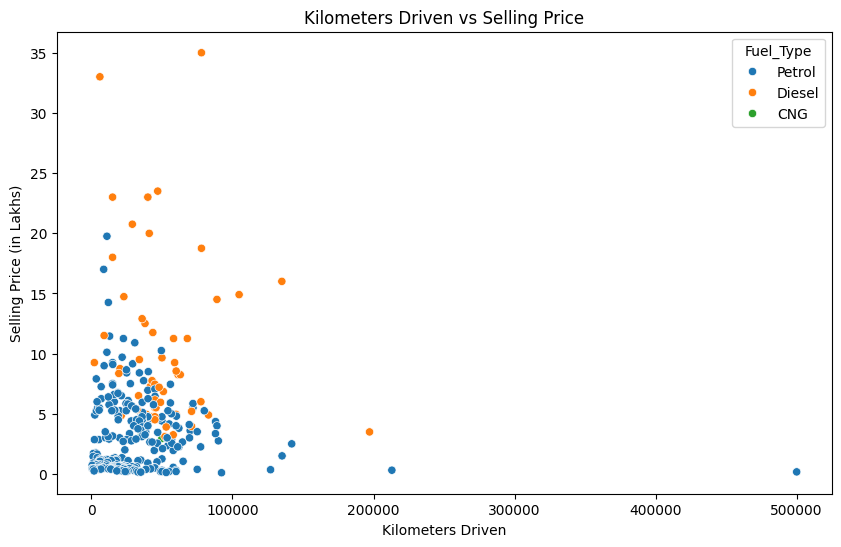

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Driven_kms', y='Selling_Price', hue='Fuel_Type', data=df)

plt.title("Kilometers Driven vs Selling Price")

plt.xlabel("Kilometers Driven")

plt.ylabel("Selling Price (in Lakhs)")

plt.show()

### Correlation Heatmap

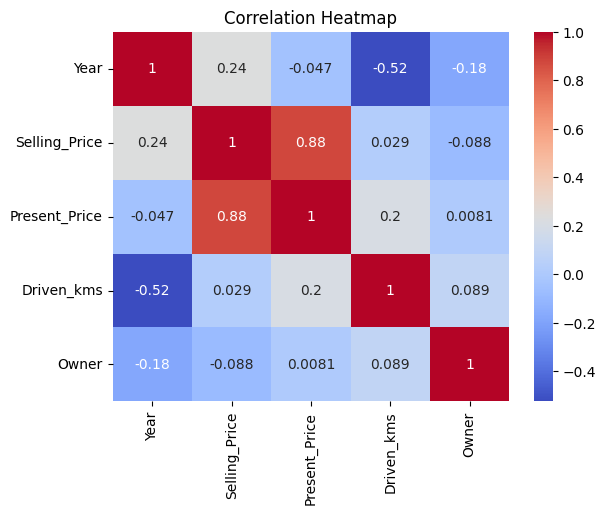

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Data Preprocessing — Feature Engineering

In [ ]:
# Calculate car age from Year
df['Car_Age'] = 2024 - df['Year']

# Encode categorical columns
df['Fuel_Type'] = df['Fuel_Type'].map({'Petrol': 0, 'Diesel': 1, 'CNG': 2})

df['Selling_type'] = df['Selling_type'].map({'Dealer': 0, 'Individual': 1})

df['Transmission'] = df['Transmission'].map({'Manual': 0, 'Automatic': 1})

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
0     ritz  2014           3.35           5.59       27000          0   
1      sx4  2013           4.75           9.54       43000          1   
2     ciaz  2017           7.25           9.85        6900          0   
3  wagon r  2011           2.85           4.15        5200          0   
4    swift  2014           4.60           6.87       42450          1   

   Selling_type  Transmission  Owner  Car_Age  
0             0             0      0       10  
1             0             0      0       11  
2             0             0      0        7  
3             0             0      0       13  
4             0             0      0       10  


### Preparing Features and Target Variable

In [ ]:
X = df[['Car_Age', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']]

y = df['Selling_Price']

print("Features shape:", X.shape)

print("Target shape:", y.shape)

Features shape: (301, 7)
Target shape: (301,)


In [ ]:
### Splitting the Dataset into Train and Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)

print("Testing set size:", X_test.shape)

Training set size: (240, 7)
Testing set size: (61, 7)


### Training — Linear Regression Model

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


### Training — Random Forest Regressor Model

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


### Model Evaluation

In [ ]:
print("=== Linear Regression ===")
print("MAE :", round(mean_absolute_error(y_test, lr_predictions), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_predictions)), 4))
print("R2  :", round(r2_score(y_test, lr_predictions), 4))

print()

print("=== Random Forest Regressor ===")
print("MAE :", round(mean_absolute_error(y_test, rf_predictions), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_predictions)), 4))
print("R2  :", round(r2_score(y_test, rf_predictions), 4))

=== Linear Regression ===
MAE : 1.2219
RMSE: 1.8792
R2  : 0.8467

=== Random Forest Regressor ===
MAE : 0.6525
RMSE: 0.9805
R2  : 0.9583


### Actual vs Predicted Selling Price — Random Forest

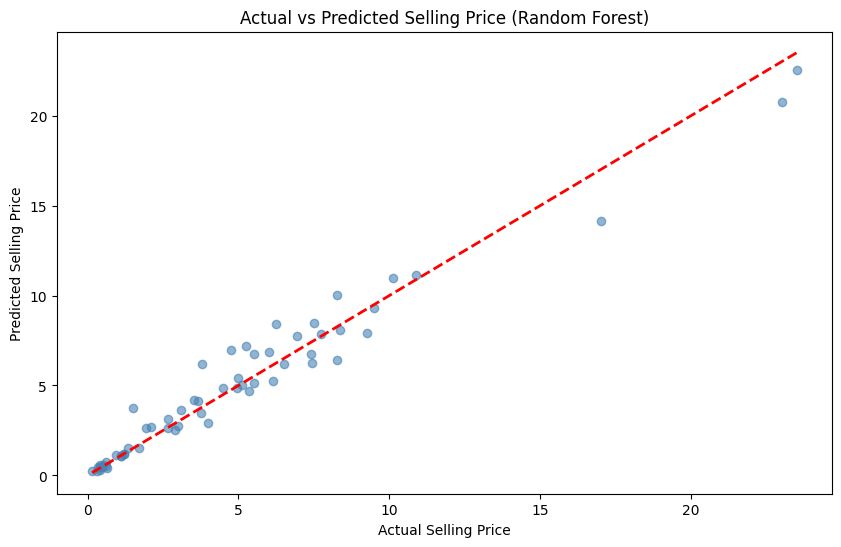

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, rf_predictions, color='steelblue', alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title("Actual vs Predicted Selling Price (Random Forest)")

plt.xlabel("Actual Selling Price")

plt.ylabel("Predicted Selling Price")

plt.show()

### Feature Importance — Random Forest

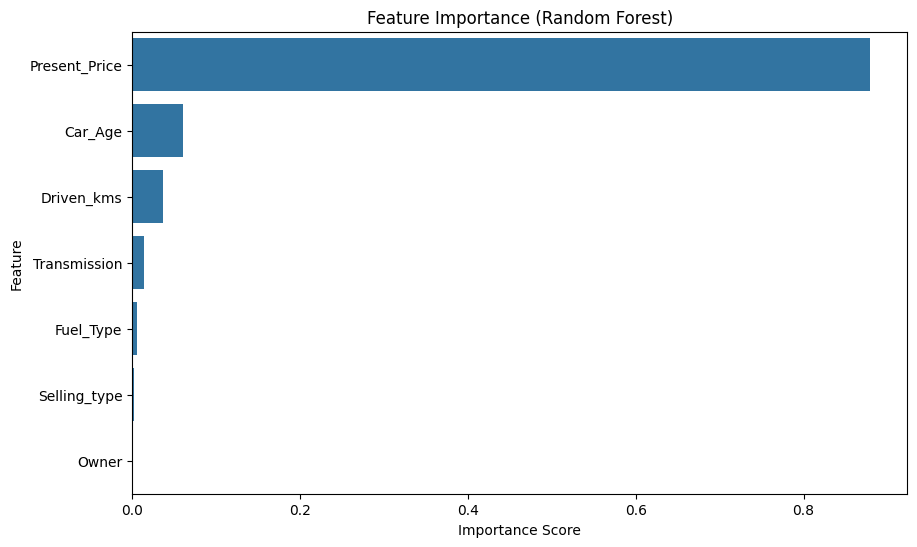

In [ ]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x=feature_importance, y=feature_importance.index)

plt.title("Feature Importance (Random Forest)")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

### Average Selling Price

In [ ]:
average_price = df['Selling_Price'].mean()

print("Average Selling Price:", round(average_price, 2), "Lakhs")

Average Selling Price: 4.66 Lakhs


## Conclusion

The car price dataset was successfully analyzed and used to train machine learning models. Two models were built — Linear Regression and Random Forest Regressor. The Random Forest model outperformed Linear Regression with a higher R2 score and lower error metrics. Key features influencing car prices include Present Price and Car Age. The project demonstrates how machine learning can be applied to predict used car prices effectively.